For comparison, we will write our own matrix multiply function and run it against the same benchmark. The textbook matrix muliply algorithm runs in O(n^3)

Generalized Matrix Multiplication (GEMM) is defined according to the level 3 Basic Linear Algebra Subpackage (BLAS) specification as follows:
$$
C \leftarrow \alpha AB + \beta C
$$
The matrix-multiply is only defined for operands $A \in \mathbb{R}^{m\times k}$, $B \in \mathbb{R}^{k \times n}$, and $C \in \mathbb{R}^{m \times n}$. For simplicity, let us assume that $\beta =0$ and $\alpha=1$. Today, I want to tackle the problem of computing a SGEMM (Gemm with 32-bit floating point operands) as efficiently as possible. For now, I want to define "efficient" very vaguely. I simply want the result before I lose patience with my computer (an unfortunately common occurence). 

[comment]: # (The 3 operands matrices A, B, and C are all $n\times n$ and contain 32-bit floating point numbers. We run the SGEMM for the sizes in the geometric range $n \in \{ 1, 2, \ldots 8192 \}$)

In [ ]:
def matrix_multiplication(A, B, C, alpha=1.0, beta=0.0):
    

In [13]:
import time
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from functools import reduce
import operator

# Each record is a pair of the problem `shape` and sequence of `timings` (a single run of the kernel) in ns
BenchmarkRecord = namedtuple("MatmultBenchmark", ("shape", "timings"))

RAND_SEED=0
results = {}
#tmp = []

def benchmark(matmul_kernel, shape, dtype=np.float32):
    """Benchmark a specific matmult kernel `matmult_kernel` with shape `shape`
    Returns a BenchmarkRecord
    """
    m, n, k = shape
    rng = np.random.default_rng(RAND_SEED)
    A = rng.standard_normal((m, k)).astype(dtype)
    B = rng.standard_normal((k, n)).astype(dtype)
    C = np.zeros((m, n), dtype=dtype)
    flops = 2 * m * n * k

    C = matmul_kernel(A, B)
    timings = []
    for _ in range(10):
        t_start = time.perf_counter_ns()
        C = matmul_kernel(A, B)
        timings.append(time.perf_counter_ns() - t_start)
    return BenchmarkRecord((m, n, k), tuple(timings))

def benchmark_square_matrices(matmul_kernel, n_limit):
    """Benchmark square SGEMM for size N
    N is a power of 2 up to and including n_limit
    """
    tmp = []
    for n in (2**i for i in range(n_limit.bit_length())):
        tmp.append(benchmark(matmul_kernel, (n, n, n)))
    results[matmul_kernel.__name__] = tmp

def matmult_flops(record):
    return reduce(mult, record.shape, 2)

In [9]:
""" O(n^3) Textbook algorithm
"""
def matmult(A, B, C):
    M, K = A.shape
    K, N = B.shape
    assert M, N == C.shape
    for i in  range(M):
        for j in range(N):
            acc = 0.0
            for k in range(K):
                acc += A[i, k] * B[k, j]
            C[i, j] = acc
    return C
            
""" As a sanity check let's verify the result with what numpy computes
"""
def verify(A, B, C):
    assert np.allclose(matmult(A, B, C), A@B, atol=1e-3)

n = 1
flops = []
rng = np.random.default_rng(0)
while n<=2048:
    A = rng.standard_normal((n, n)).astype(np.float32)
    B = rng.standard_normal((n, n)).astype(np.float32)
    C = np.zeros((n,n), dtype=np.float32)
    verify(A, B, C)
    best = np.inf
    for _ in range(10):
        t0 = time.perf_counter_ns()
        C = matmult(A, B, C)
        best = min(best, time.perf_counter_ns() - t0)
    # flops[i] = GFLOPS for N=2^i
    flops.append(2*n**3/best)
    #print(f"N= {n}, GFLOPS/s= {(2*n**3)/best}")
    n *= 2

fig, ax = plt.subplots()
X = np.array([2**i for i in range(len(flops))])
Y = np.array(flops)
ax.plot(X, Y, label="flops VS n")

ax.set(title="PEAK FLOPS", xlabel="n", ylabel="GFLOPS")
ax.legend()
ax.grid()

fig.tight_layout()
plt.show()

KeyboardInterrupt: 

First we will do some back-of-the-envelope calculation to calculate our peak FLOPS and peak memory bandwidth. Our computer has a AMD Zen 3+ processor which supports the AVX2 extension for X86-64. This [document](https://www.agner.org/optimize/instruction_tables.pdf) lists the instruction latencies for AMD's Zen 3 microarchitecture. `VFMADD` takes operands from the 256-bit `YMMx` registers. This particular instruction has a latency of 4 cycles and throughput of 2 instructions/cycle due to the usage of two vector pipes VP0/1. Fully utlizing the pipeline will require us to have 8 in-flight Fused Multiply-Add (FMA) at any time. A 256-bit operand can pack 8 single-precision floats (fp32) or 4 double-precision floats (fp64). We can estimate our peak compute and memory bandwidth as follows:

$$
P = 2 \times \text{instruction\_throughput} \times \text{num\_packed\_floats} \times f_{clock} \text{ FLOPS/s}
$$

$$
B = \text{transfer\_rate} \times \text{bus\_width}
$$

Our computer's processor can operate at a max frequency of 4.7GHz and we can get a peak fp32 compute throughput of 150.4GFLOPS/s. Memory bandwidth will depend upon the DDR generation machine configuration. Our computer's memory is LPDDR5 configured at 6400 MT/s with a total bus-width of 128-bit. The maximum memory bandwidth is 102GB/s.

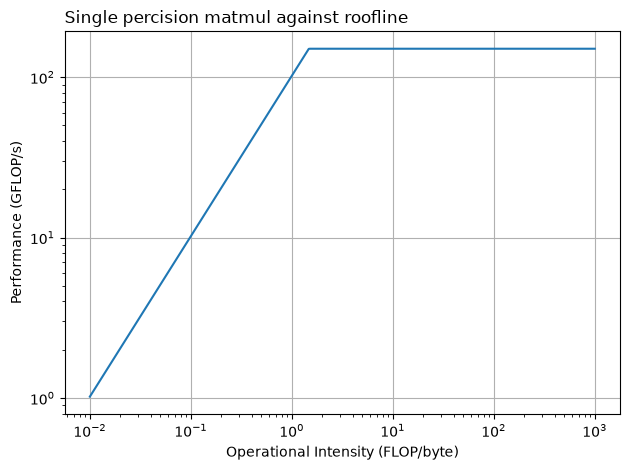

In [8]:
import matplotlib.pyplot as plt

PEAK_GFLOPS, PEAK_BW = 150.4, 102


oi = 
fig, ax = plt.subplots()
X = np.logspace(-2, 3, 400)
ax.plot(X, np.minimum(PEAK_GFLOPS, PEAK_BW*X))
# ax.axvline(ridge, ls=":")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Operational Intensity (FLOP/byte)")
ax.set_ylabel("Performance (GFLOP/s)")
ax.set_title("Single percision matmul against roofline", loc="left")
ax.grid(True)
fig.tight_layout()
plt.show()